# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [6]:
import pandas as pd
train = pd.read_csv('heart_cleveland_upload.csv')
train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


### Exploratory Data Analysis

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [8]:
d = train.describe()
d

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


C:\Users\user\AppData\Local\Temp\ipykernel_19852\3620128989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='condition',data=train,palette='RdBu_r')


<Axes: xlabel='condition', ylabel='count'>

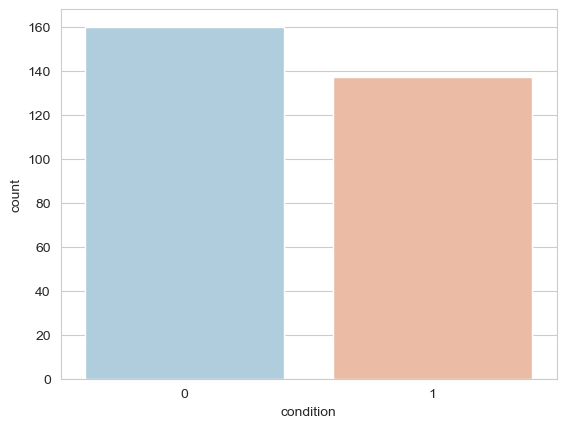

In [9]:
# Cek relative size dari condition 0 dan 1
sns.set_style('whitegrid')
sns.countplot(x='condition',data=train,palette='RdBu_r')

<Axes: xlabel='condition', ylabel='count'>

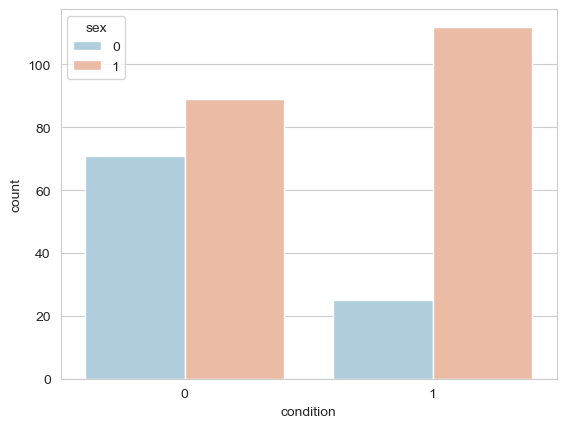

In [10]:
# Condition vs sex
sns.set_style('whitegrid')
sns.countplot(x='condition',hue='sex',data=train,palette='RdBu_r')

<Axes: xlabel='condition', ylabel='count'>

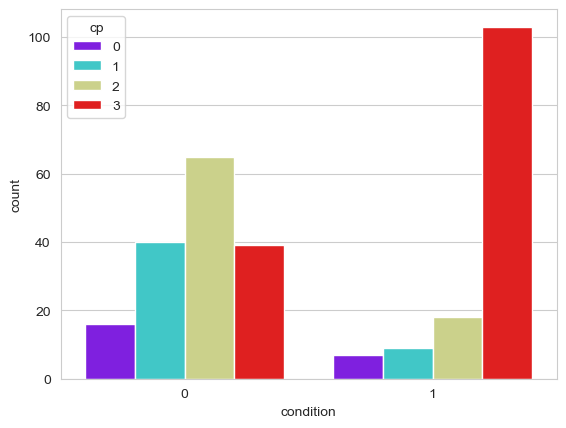

In [11]:
# Condition vs cp
sns.set_style('whitegrid')
sns.countplot(x='condition',hue='cp',data=train,palette='rainbow')

Text(0.5, 1.0, 'Persentase condition berdasarkan cp')

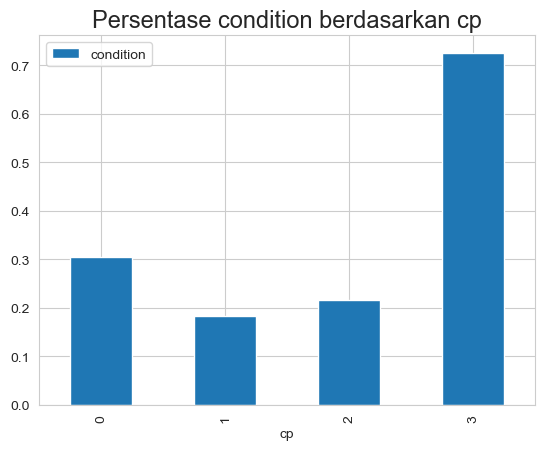

In [12]:
f_cp_condition=train.groupby('cp')['condition'].mean()
f_cp_condition = pd.DataFrame(f_cp_condition)
f_cp_condition.plot.bar(y='condition')
plt.title("Persentase condition berdasarkan cp",fontsize=17)

<Axes: xlabel='condition', ylabel='count'>

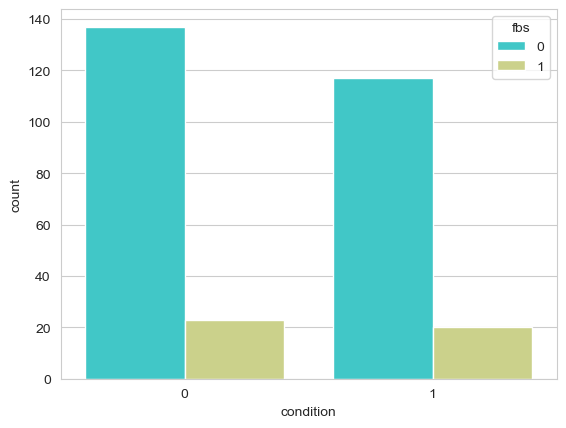

In [13]:
# Condition vs fbs
sns.set_style('whitegrid')
sns.countplot(x='condition',hue='fbs',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram usia pasien'}, xlabel='Usia pasien', ylabel='Count'>

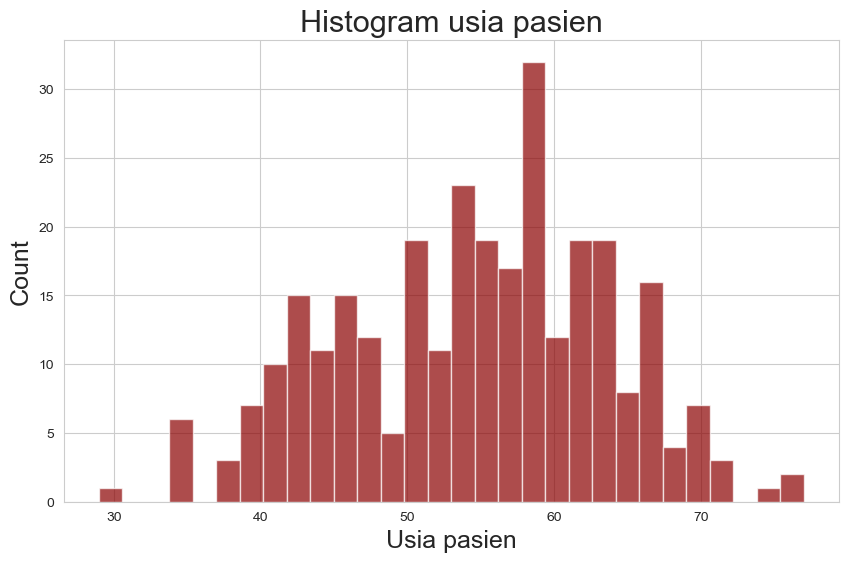

In [14]:
# Cek distribusi dari umur
plt.xlabel("Usia pasien",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia pasien",fontsize=22)
train['age'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

C:\Users\user\AppData\Local\Temp\ipykernel_19852\433714939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cp',y='age',data=train,palette='winter')


<Axes: xlabel='Chest Pain Type (cp)', ylabel='Age'>

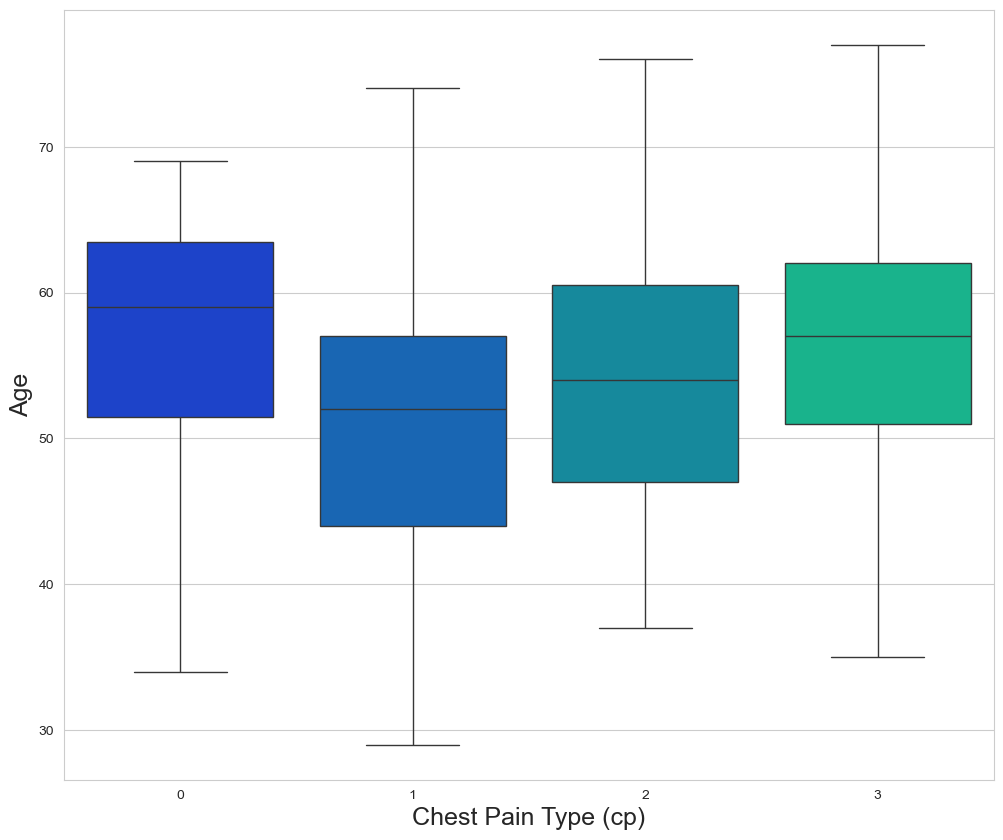

In [15]:
# Distribusi umur di setiap cp
plt.figure(figsize=(12, 10))
plt.xlabel("Chest Pain Type (cp)",fontsize=18)
plt.ylabel("Age",fontsize=18)
sns.boxplot(x='cp',y='age',data=train,palette='winter')

Text(0.5, 0, 'Chest pain type')

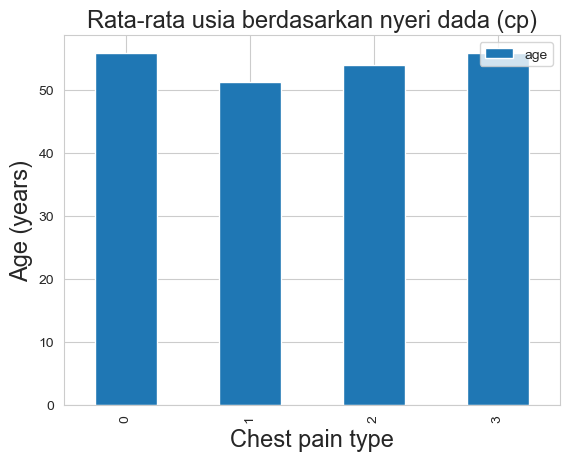

In [16]:
f_cp_Age=train.groupby('cp')['age'].mean()
f_cp_Age = pd.DataFrame(f_cp_Age)
f_cp_Age.plot.bar(y='age')
plt.title("Rata-rata usia berdasarkan nyeri dada (cp)",fontsize=17)
plt.ylabel("Age (years)", fontsize=17)
plt.xlabel("Chest pain type", fontsize=17)

### Fitur Engineering

In [17]:
# Dataset heart_cleveland_upload.csv tidak memiliki missing value.
# Tidak perlu imputasi.

In [18]:
# Tidak perlu apply imputasi.

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

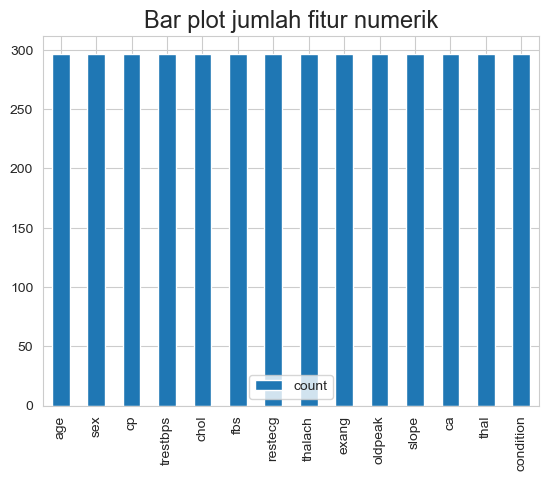

In [19]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [20]:
# Tidak ada kolom yang di-drop karena tidak ada null value yang ekstrim
train.dropna(inplace=True)
train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [21]:
# Drop semua kolom yang tidak penting
# Pada dataset ini semua fitur penting dan sudah numerik, jadi kita biarkan
train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [22]:
# Semua data sudah numerik, tidak perlu Label Encoding
train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


### Training

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('condition',axis=1),
                                                    train['condition'], test_size=0.30,
                                                    random_state=42)

In [24]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (207, 13)
Test shape: (90, 13)


# **KNN**

In [25]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred = clf1.predict(X_test)

### Evaluation

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.59
Confusion Matrix:
[[33 15]
 [22 20]]
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.69      0.64        48
           1       0.57      0.48      0.52        42

    accuracy                           0.59        90
   macro avg       0.59      0.58      0.58        90
weighted avg       0.59      0.59      0.58        90



# **Naive Bayes**

In [28]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.80
Confusion Matrix:
[[37 11]
 [ 7 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        48
           1       0.76      0.83      0.80        42

    accuracy                           0.80        90
   macro avg       0.80      0.80      0.80        90
weighted avg       0.80      0.80      0.80        90



# **Decision Tree**

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.73
Confusion Matrix:
[[34 14]
 [10 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        48
           1       0.70      0.76      0.73        42

    accuracy                           0.73        90
   macro avg       0.73      0.74      0.73        90
weighted avg       0.74      0.73      0.73        90



Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [32]:
# Data pasien baru
# Format: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
new_data = np.array([[60, 1, 0, 140, 200, 0, 1, 150, 0, 1.5, 1, 0, 0]])

# Prediksi kelas
new_prediction = nb.predict(new_data)
print("Prediksi Kondisi (0 = Tidak Sakit, 1 = Sakit):", new_prediction[0])

# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas Prediksi [Tidak Sakit, Sakit]:", proba[0])

Prediksi Kondisi (0 = Tidak Sakit, 1 = Sakit): 0
Probabilitas Prediksi [Tidak Sakit, Sakit]: [0.97778865 0.02221135]


c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [33]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.58
Confusion Matrix:
[[32 16]
 [22 20]]
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.67      0.63        48
           1       0.56      0.48      0.51        42

    accuracy                           0.58        90
   macro avg       0.57      0.57      0.57        90
weighted avg       0.58      0.58      0.57        90



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.705343   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.705343   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.700465   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.690708   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.686063   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.686063   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.676307   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.671429   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.647271   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.647154   
1   {'metric': 'euclidean', 'n_neighbors

In [36]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [37]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


In [38]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.62
Presisi:  0.62
Recall:   0.62
F1-Score: 0.62

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.67      0.65        48
           1       0.60      0.57      0.59        42

    accuracy                           0.62        90
   macro avg       0.62      0.62      0.62        90
weighted avg       0.62      0.62      0.62        90

Confusion Matrix:
[[32 16]
 [18 24]]


In [39]:
import numpy as np

# Data pasien baru (dalam urutan sama seperti fitur model)
new_data_1 = np.array([[60, 1, 0, 140, 200, 0, 1, 150, 0, 1.5, 1, 0, 0]])

# Prediksi apakah pasien ini sakit atau tidak
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Tidak Sakit, 1 = Sakit):", prediction[0])

Prediksi (0 = Tidak Sakit, 1 = Sakit): 1


c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
